# Row 2: The re-marked GEX level at 10:00 sets the rest-of-day range

In [1]:
import sys, json, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R, gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy")
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


{
 "rest_of_day_by_1000_tercile": {
  "low third": 1.745,
  "middle": 1.117,
  "high third": 0.905
 },
 "rest_of_day_by_sign_and_size": {
  "negative small": 1.153,
  "negative medium": 1.248,
  "negative large": 1.875,
  "positive small": 1.014,
  "positive medium": 0.914,
  "positive large": 0.826
 },
 "p_low_vs_high": 5.069089253173186e-49,
 "n_days": 743
}


,next 30 min,next 1 h,next 2 h,rest of day
10:00,-0.55 (-0.52),-0.57 (-0.56),-0.59 (-0.57),-0.58 (-0.54)
10:30,-0.51 (-0.48),-0.54 (-0.51),-0.59 (-0.55),-0.58 (-0.52)
11:30,-0.57 (-0.48),-0.60 (-0.52),-0.61 (-0.53),-0.59 (-0.50)
12:30,-0.55 (-0.44),-0.58 (-0.49),-0.56 (-0.46),-0.56 (-0.47)
14:00,-0.45 (-0.33),-0.50 (-0.38),-0.54 (-0.42),-0.54 (-0.42)


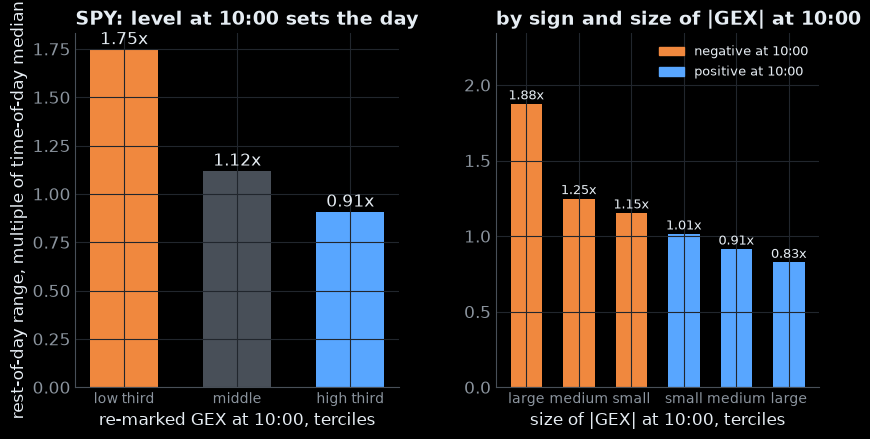

In [2]:
res = R.row2(ctx)
print(json.dumps({k: v for k, v in R.show(res).items() if 'horizon' not in k}, indent=1))
display(pd.DataFrame({t: {h: f'{a:+.2f} ({b:+.2f})' for h, (a, b) in d.items()} for t, d in res['spearman_by_time_and_horizon (re-mark, stale)'].items()}).T)
_ = R.fig2(ctx, res, G.FIGURES / 'row02_level_at_1000.png')

In [3]:
R.per_name({'r2_spearman_1000_rest': 'Spearman, 10:00 level vs rest of day', 'r2_rest_low_third': 'rest of day, low third', 'r2_rest_high_third': 'rest of day, high third'}).round(3)

,"Spearman, 10:00 level vs rest of day","rest of day, low third","rest of day, high third"
symbol,,,
SPY,-0.577,1.745,0.905
QQQ,-0.520,1.480,0.888
IWM,-0.251,1.339,1.052
NVDA,-0.179,1.236,1.112
TSLA,0.045,1.133,1.193
AAPL,-0.200,1.207,1.069
AMZN,-0.253,1.271,1.070
META,-0.152,1.145,1.086
MSFT,-0.179,1.201,1.063
